### 1. Library Imports
We import key data libraries (`numpy`, `pandas`), plotting tools (`matplotlib`, `seaborn`), and `scikit-learn` utilities for preprocessing (scaling, label encoding), dataset splitting, logistic regression modeling, and classification model performance metrics.


In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler,  LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, 
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix, 
    classification_report
)

### 2. Loading the Dataset
We load the Titanic dataset from the `Datasets` folder using `pd.read_csv()`. We use a relative path (`../../Datasets/titanic.csv`) since our notebook is located two folders deep within the directory structure.


In [ ]:
df = pd.read_csv("../../Datasets/titanic.csv")

### 3. Inspecting the First and Last Rows
We check the first and last five rows of our dataset using `.head()` and `.tail()` to visually verify that the data loaded correctly and to understand its general structure.


In [8]:
print(df.head())
print()
print(df.tail())

   PassengerId                                               Name  Pclass  \
0            1                            Braund, Mr. Owen Harris       3   
1            2  Cumings, Mrs. John Bradley (Florence Briggs Th...       1   
2            3                             Heikkinen, Miss. Laina       3   
3            4       Futrelle, Mrs. Jacques Heath (Lily May Peel)       1   
4            5                           Allen, Mr. William Henry       3   

      Sex   Age  SibSp  Parch            Ticket     Fare Cabin Embarked  \
0    male  22.0      1      0         A/5 21171   7.2500   NaN        S   
1  female  38.0      1      0          PC 17599  71.2833   C85        C   
2  female  26.0      0      0  STON/O2. 3101282   7.9250   NaN        S   
3  female  35.0      1      0            113803  53.1000  C123        S   
4    male  35.0      0      0            373450   8.0500   NaN        S   

   Survived  
0         0  
1         1  
2         1  
3         1  
4         0  

 

### 4. Dimensions of the Dataset
We inspect the `.shape` attribute to check the total number of rows (passengers) and columns (features + target) in the dataset.


In [9]:
df.shape

(891, 12)

### 5. Column Metadata and Data Types
We call `.info()` to display column names, data types, and count non-null values. This highlights columns with significant missing values (like `Cabin` and `Age`).


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Name         891 non-null    str    
 2   Pclass       891 non-null    int64  
 3   Sex          891 non-null    str    
 4   Age          714 non-null    float64
 5   SibSp        891 non-null    int64  
 6   Parch        891 non-null    int64  
 7   Ticket       891 non-null    str    
 8   Fare         891 non-null    float64
 9   Cabin        204 non-null    str    
 10  Embarked     889 non-null    str    
 11  Survived     891 non-null    int64  
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


### 6. Summary Statistics
We run `.describe()` to view descriptive statistics for the numerical features, giving us an idea of the distribution, range, mean, and potential outliers in the dataset.


In [11]:
df.describe()

,PassengerId,Pclass,Age,SibSp,Parch,Fare,Survived
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,2.308642,29.699118,0.523008,0.381594,32.204208,0.383838
std,257.353842,0.836071,14.526497,1.102743,0.806057,49.693429,0.486592
min,1.000000,1.000000,0.420000,0.000000,0.000000,0.000000,0.000000
25%,223.500000,2.000000,20.125000,0.000000,0.000000,7.910400,0.000000
50%,446.000000,3.000000,28.000000,0.000000,0.000000,14.454200,0.000000
75%,668.500000,3.000000,38.000000,1.000000,0.000000,31.000000,1.000000
max,891.000000,3.000000,80.000000,8.000000,6.000000,512.329200,1.000000


### 7. Checking for Missing (Null) Values
We compute the sum of null values for each column to plan our data cleaning and imputation strategies.


In [12]:
df.isnull().sum()

PassengerId      0
Name             0
Pclass           0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
Survived         0
dtype: int64

### 8. Checking for Duplicate Records
We check for identical duplicate rows to ensure we don't have redundant information that might bias our model.


In [13]:
df.duplicated().sum()

np.int64(0)

### 9. Dropping the 'Cabin' Column
We drop the `Cabin` column because it is missing more than 70% of its values and cannot be reliably imputed.


In [ ]:
df.drop("Cabin", axis=1, inplace=True)

### 10. Inspecting Remaining Columns
We list the remaining columns to ensure the `Cabin` column was successfully removed.


In [16]:
df.columns

Index(['PassengerId', 'Name', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Embarked', 'Survived'],
      dtype='str')

### 11. Handling Missing 'Embarked' Values
Since the `Embarked` column only has 2 missing values, we drop those two rows directly from the dataset.


In [22]:
df.dropna(subset=["Embarked"], inplace=True)

### 12. Imputing Missing 'Age' Values
We fill the missing values in the `Age` column with the mean age of the passengers, making the column complete.


In [26]:
df.fillna(df["Age"].mean(), inplace=True)

,PassengerId,Name,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Survived
0,1,"Braund, Mr. Owen Harris",3,male,22.000000,1,0,A/5 21171,7.2500,S,0
1,2,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,female,38.000000,1,0,PC 17599,71.2833,C,1
2,3,"Heikkinen, Miss. Laina",3,female,26.000000,0,0,STON/O2. 3101282,7.9250,S,1
3,4,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,female,35.000000,1,0,113803,53.1000,S,1
4,5,"Allen, Mr. William Henry",3,male,35.000000,0,0,373450,8.0500,S,0
...,...,...,...,...,...,...,...,...,...,...,...
886,887,"Montvila, Rev. Juozas",2,male,27.000000,0,0,211536,13.0000,S,0
887,888,"Graham, Miss. Margaret Edith",1,female,19.000000,0,0,112053,30.0000,S,1
888,889,"Johnston, Miss. Catherine Helen ""Carrie""",3,female,29.642093,1,2,W./C. 6607,23.4500,S,0
889,890,"Behr, Mr. Karl Howell",1,male,26.000000,0,0,111369,30.0000,C,1


### 13. Dropping the 'Name' Column
We drop the `Name` column because passenger names are unique text strings and do not help the model generalize survival rules.


In [31]:
df.drop("Name", axis=1, inplace=True)

### 14. Dropping the 'Ticket' Column
We drop the `Ticket` column because ticket numbers have very high cardinality and lack predictive value.


In [34]:
df.drop("Ticket", axis=1, inplace=True)

### 15. Dropping 'PassengerId'
We remove `PassengerId` because it is a unique serial number that provides no predictive signal and could cause overfitting.


In [37]:
df.drop(columns=["PassengerId"], inplace=True)

### 16. Encoding Categorical Variables
We use `LabelEncoder` to convert categorical variables (`Sex` and `Embarked`) into numerical formats (0, 1, 2). We then cast the entire DataFrame to integers to standardize data types.


In [52]:
encoder = LabelEncoder()

df["Sex"] = encoder.fit_transform(df["Sex"])
df["Embarked"] = encoder.fit_transform(df["Embarked"])

df = df.astype(int)
df

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Survived,FamilySize,IsAlone
0,3,1,22,1,0,7,2,0,2,0
1,1,0,38,1,0,71,0,1,2,0
2,3,0,26,0,0,7,2,1,1,1
3,1,0,35,1,0,53,2,1,2,0
4,3,1,35,0,0,8,2,0,1,1
...,...,...,...,...,...,...,...,...,...,...
886,2,1,27,0,0,13,2,0,1,1
887,1,0,19,0,0,30,2,1,1,1
888,3,0,29,1,2,23,2,0,4,0
889,1,1,26,0,0,30,0,1,1,1


### 17. Feature Engineering
We create:
- `FamilySize` (combining `SibSp` and `Parch` plus 1 for the passenger) to capture social groups.
- `IsAlone` (binary indicator) to distinguish solo travelers, which historically had different survival priorities.
- Introducing  `FamilySize` and `IsAlone` gave the model direct indicators of social groups on the ship. Historically, families and solo travelers had very different evacuation priorities ("women and children first"), and the model was able to utilize these features to make cleaner classification splits.


In [51]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

### 18. Splitting Features (X) and Target (y)
We split our cleaned dataset into independent variables (features `X`) and the dependent target variable (survived or not `y`).


In [53]:
X = df.drop("Survived", axis=1)
y = df["Survived"]

### 19. Train-Test Split
We partition the data into an 80% training set and a 20% test set, using a random state to guarantee reproducibility.


In [54]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### 20. Feature Scaling (Standardization)
We use `StandardScaler` to normalize our features so they have a mean of 0 and standard deviation of 1. This prevents features with larger scales from dominating the logistic regression loss function.


In [55]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 21. Training the Logistic Regression Model
We fit our Logistic Regression classifier on the scaled training dataset to learn the classification boundaries.


In [56]:
logReg_model = LogisticRegression()

logReg_model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

### 22. Generating Predictions
We generate class predictions on the scaled test set using our trained model.


In [57]:
y_pred = logReg_model.predict(X_test_scaled)

y_pred

array([0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0,
       0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0,
       0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0,
       0, 1])

### 23. Model Evaluation
We evaluate the model using Accuracy, Precision, Recall, and F1-score, plot the Confusion Matrix heatmap to visualize false positives/negatives, and print a full classification report.


Accuracy:  0.8034
Precision: 0.7361
Recall:    0.7681
F1-Score:  0.7518


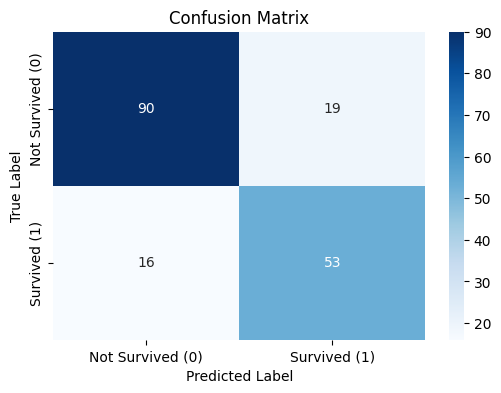

Classification Report

              precision    recall  f1-score   support

           0       0.85      0.83      0.84       109
           1       0.74      0.77      0.75        69

    accuracy                           0.80       178
   macro avg       0.79      0.80      0.79       178
weighted avg       0.81      0.80      0.80       178



In [64]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)


print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")


plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Survived (0)', 'Survived (1)'],
            yticklabels=['Not Survived (0)', 'Survived (1)'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


print("Classification Report\n")
print(classification_report(y_test, y_pred))

### 24. Analyzing Feature Coefficients (Weights)
We plot the coefficients of our model as a 1D heatmap using a `coolwarm` palette. This shows the direction and magnitude of each feature's contribution to the probability of survival.


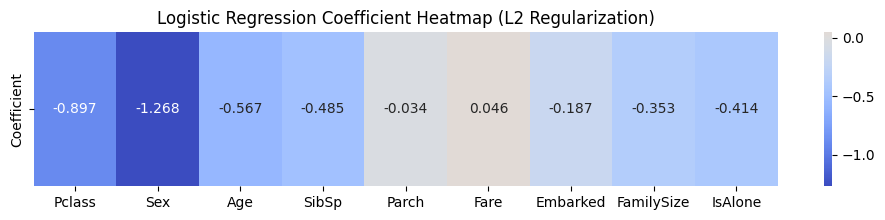

In [ ]:
coef_df = pd.DataFrame(logReg_model.coef_, columns=X.columns, index=['Coefficient'])

plt.figure(figsize=(12, 2))
sns.heatmap(coef_df, annot=True, cmap='coolwarm', center=0, fmt=".3f", cbar=True)
plt.title("Logistic Regression Coefficient Heatmap (L2 Regularization)")
plt.show()